# Checkpoint Two: Exploratory Data Analysis

Now that your chosen dataset is approved, it is time to start working on your analysis. Use this notebook to perform your EDA and make notes where directed to as you work.

## Getting Started

Since we have not provided your dataset for you, you will need to load the necessary files in this repository. Make sure to include a link back to the original dataset here as well.

My dataset: https://www.kaggle.com/datasets/chicago/chicago-transit-authority-cta-data

Your first task in EDA is to import necessary libraries and create a dataframe(s). Make note in the form of code comments of what your thought process is as you work on this setup task.

In [ ]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Load CTA bus ridership datasets:

# Daily ridership totals by route
daily_df = pd.read_csv('cta-ridership-bus-routes-daily-totals-by-route.csv')

# Monthly averages and totals by route and day type
monthly_df = pd.read_csv('cta-ridership-bus-routes-monthly-day-type-averages-totals.csv')

# Preview the data to confirm successful load
monthly_df.head()
daily_df.head()


/var/folders/r9/rmnbmvdd6qn80qqjqcl3h1tc0000gn/T/ipykernel_90511/3013068873.py:7: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  daily_df = pd.read_csv('cta-ridership-bus-routes-daily-totals-by-route.csv')


,route,date,daytype,rides
0,1,2019-06-28T00:00:00.000,W,1476
1,1,2019-06-27T00:00:00.000,W,2007
2,1,2019-06-26T00:00:00.000,W,1748
3,1,2019-06-25T00:00:00.000,W,1927
4,1,2019-06-24T00:00:00.000,W,1727


## Get to Know the Numbers

Now that you have everything setup, put any code that you use to get to know the dataframe and its rows and columns better in the cell below. You can use whatever techniques you like, except for visualizations. You will put those in a separate section.

When working on your code, make sure to leave comments so that your mentors can understand your thought process.

In [ ]:
# I'm looking to understand the structure and data types of both datasets using a method and two attributes.

print(daily_df.shape) #Large dataset with 824291 rows but onlt a handful of columns
print(daily_df.columns)
print(daily_df.info())# There do not appear to be any missing values. Date column is an object and includes a timestamp.  

print(monthly_df.shape)#Large number of rows totaling 30679. Seven columns
print(monthly_df.columns) # This dataset contain both route identifiers and route names. Different from the daily sheet which only has identifiers.
print(monthly_df.info()) # This sheet has a more diverse mixutre of data types. Like the other sheet, there are no missing values. Average Ridership columns are floats, while totals are integers.


(824291, 4)
Index(['route', 'date', 'daytype', 'rides'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824291 entries, 0 to 824290
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   route    824291 non-null  object
 1   date     824291 non-null  object
 2   daytype  824291 non-null  object
 3   rides    824291 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 25.2+ MB
None
(30679, 7)
Index(['route', 'routename', 'Month_Beginning', 'Avg_Weekday_Rides',
       'Avg_Saturday_Rides', 'Avg_Sunday-Holiday_Rides', 'MonthTotal'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30679 entries, 0 to 30678
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   route                     30679 non-null  object 
 1   routename                 30679 non-null  object 
 2   Month_Beginning           

In [ ]:
# Preview a few rows from each dataset
daily_df.head() # Previewed above 
monthly_df.head() # Looks like ridership metrics are already aggregated by route and month 


,route,routename,Month_Beginning,Avg_Weekday_Rides,Avg_Saturday_Rides,Avg_Sunday-Holiday_Rides,MonthTotal
0,1,Indiana/Hyde Park,2001-01-01T00:00:00.000,6982.6,0.0,0.0,153617
1,2,Hyde Park Express,2001-01-01T00:00:00.000,1000.0,0.0,0.0,22001
2,3,King Drive,2001-01-01T00:00:00.000,21406.5,13210.7,8725.3,567413
3,4,Cottage Grove,2001-01-01T00:00:00.000,22432.2,17994.0,10662.2,618796
4,6,Jackson Park Express,2001-01-01T00:00:00.000,18443.0,13088.2,7165.6,493926


In [47]:
# I'm curious how the route information compares between the two datasets.
print(daily_df['route'].nunique()) #There are 187 unique routes in the daily dataset
print(monthly_df['route'].nunique()) #There are 183 unique routes in the monthly dataset. Slightly fewer than in the daily dataset.

187
183


In [48]:
# What are the total date ranges
print(daily_df['date'].min(), daily_df['date'].max())
print(monthly_df['Month_Beginning'].min(), monthly_df['Month_Beginning'].max()) #Looks like just over 18 years in both datasets

2001-01-01T00:00:00.000 2019-06-30T00:00:00.000
2001-01-01T00:00:00.000 2019-06-01T00:00:00.000


In [71]:
print(daily_df.describe()) #The standard deviation is almost as high as the mean. Min ridership is 0. I assume some routes are closed for holidays or are shutdown due to resource allocation. 
monthly_df.describe() #Max routs are very large. I'm guessing there is some uneven distribution of ridership across routes.

               rides
count  824291.000000
mean     6512.523138
std      6470.979928
min         0.000000
25%      1466.000000
50%      4189.000000
75%      9888.000000
max     45177.000000


,Avg_Weekday_Rides,Avg_Saturday_Rides,Avg_Sunday-Holiday_Rides,MonthTotal
count,30679.000000,30679.000000,30679.000000,3.067900e+04
mean,6711.495251,4248.933440,2953.886007,1.749749e+05
std,6774.153602,5346.678331,3833.633574,1.841529e+05
min,0.000000,0.000000,0.000000,1.000000e+00
25%,1362.350000,0.000000,0.000000,3.175700e+04
50%,4106.200000,1966.700000,1239.100000,1.018370e+05
75%,10487.750000,6847.100000,4844.650000,2.729990e+05
max,37787.200000,30644.600000,24110.900000,1.058879e+06


## Visualize

Create any visualizations for your EDA here. Make note in the form of code comments of what your thought process is for your visualizations.

In [54]:
import matplotlib.pyplot as plt

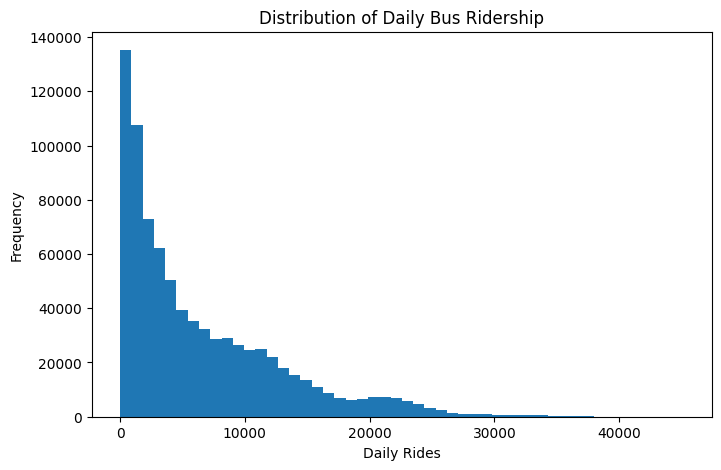

In [ ]:
#Daily data appears to be heavily skewed from the above insights. I'd like to visualize the distribution of daily ridership totals.

plt.figure(figsize=(8, 5))
plt.hist(daily_df['rides'], bins=50)
plt.xlabel('Daily Rides')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Bus Ridership')
plt.show()


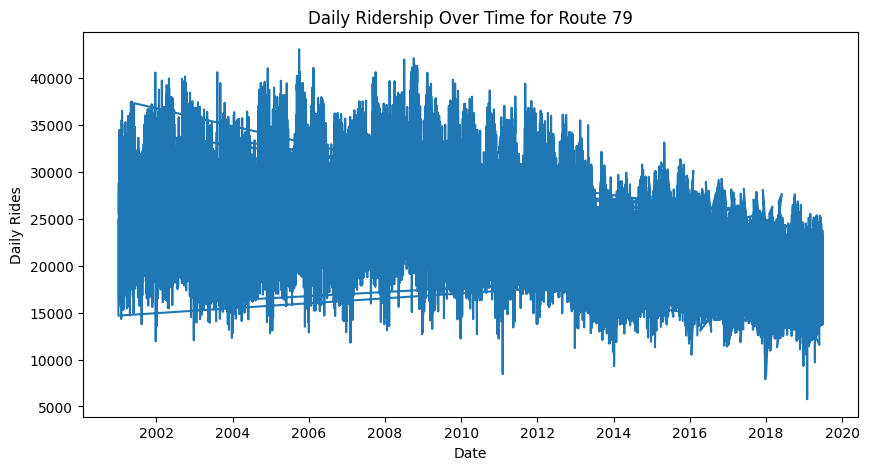

In [61]:
# Looking to make the time work better for the next plot 
daily_df['date_parsed'] = pd.to_datetime(daily_df['date'])

# Pulling a high volume route in the hopes of visualizing high variability. 
top_route = (
    daily_df
    .groupby('route')['rides']
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

route_df = daily_df[daily_df['route'] == top_route]

plt.figure(figsize=(10, 5))
plt.plot(route_df['date_parsed'], route_df['rides'])
plt.xlabel('Date')
plt.ylabel('Daily Rides')
plt.title(f'Daily Ridership Over Time for Route {top_route}')
plt.show()



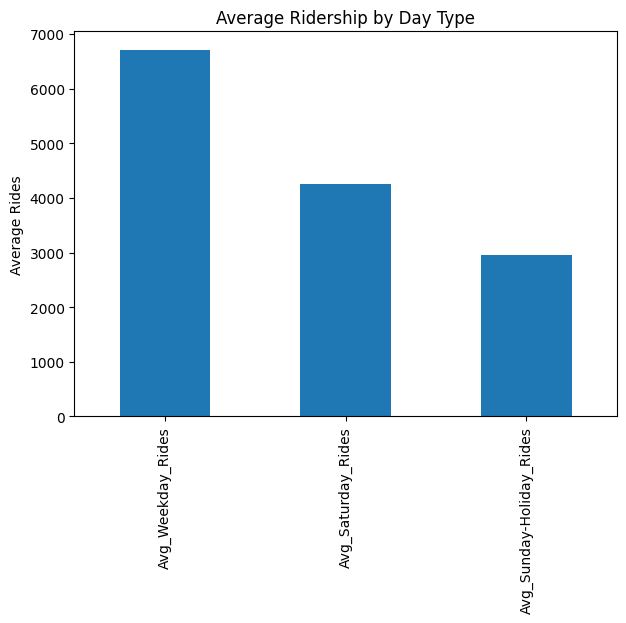

In [62]:
# Taking a look at how day of the week and holidays effect ridership
avg_by_daytype = monthly_df[
    ['Avg_Weekday_Rides', 'Avg_Saturday_Rides', 'Avg_Sunday-Holiday_Rides']
].mean()

plt.figure(figsize=(7, 5))
avg_by_daytype.plot(kind='bar')
plt.ylabel('Average Rides')
plt.title('Average Ridership by Day Type')
plt.show()


## Summarize Your Results

With your EDA complete, answer the following questions.

1. Was there anything surprising about your dataset? 

What stood out most was the level of variability in daily ridership. The standard deviation of daily rides is nearly as large as the mean, and the distribution is heavily skewed with extreme high values on certain routes and dates. Even when viewed at a monthly level, ridership remains uneven across routes and day types. This suggests that averages alone do not fully represent typical transit demand and that unpredictability is a meaningful characteristic of the system.

2. Do you have any concerns about your dataset? 

There are no major concerns regarding data completeness, as both datasets contain no missing values. However, there are several aspects that require careful interpretation. Zero-ride values appear in both daily and monthly data, which likely reflect days or routes without service rather than data errors. Additionally, the presence of extreme high values means that summary statistics such as means may be influenced by outliers, so medians or additional context may be more appropriate in some analyses.

3. Is there anything you want to make note of for the next phase of your analysis, which is cleaning data? 

For the cleaning phase, date fields should be parsed into proper datetime formats to support time based analysis. Route identifiers should be reviewed for consistency across datasets to ensure reliable joins. Zero values should be examined and retained where they reflect valid service conditions rather than missing data. Finally, the skewed distributions and large range of ridership values suggest that cleaning should focus on standardization and clarity rather than removing variability, since that variability is central to the analysis.